# Speed Dating — Data Preprocessing

Dataset: Speed Dating Experiment (OpenML ID 40536), 8378 instances, 121 attributes.

## Unit of observation

Each row is **one date**, not one person. The same participant appears in 5–22 rows
(one per partner met that evening), with identical person-level attributes
(hobbies, preferences, self-ratings) repeated across all of them.

**Decision:** we cluster **dates**, keeping all 8378 instances. Consequences:
- participants with more dates carry proportionally more weight in the clustering;
- a reconstructed `person_id` is stored in `metadata.csv`, enabling a secondary
  person-level analysis in the clustering notebook as a comparison model.

## Pipeline

1. Load and inspect
2. Remove redundant, administrative, and unusable attributes
3. Validate against domain rules (value ranges, weight sums)
4. Group the free-text `field` attribute
5. Analyse missingness (MNAR check)
6. Encode categorical attributes
7. Block-normalize so each concept contributes equally
8. Two-stage imputation: within-person recovery, then kNN
9. Save processed data and fitted models

The target `match` is **excluded from clustering** and kept in `metadata.csv`
for interpreting the resulting clusters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
from sklearn.datasets import fetch_openml

speed_dating = fetch_openml(data_id=40536, as_frame=True)
df = speed_dating.frame

print("Dataset loaded successfully.")
print(f"Number of instances (rows): {df.shape[0]}")
print(f"Number of attributes (columns): {df.shape[1]}")

Dataset loaded successfully.
Number of instances (rows): 8378
Number of attributes (columns): 121


In [3]:
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,35.0,20.0,20.0,20.0,0.0,5.0,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],6.0,8.0,8.0,8.0,8.0,6.0,[6-8],[6-8],[6-8],[6-8],[6-8],[6-8],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],6.0,9.0,7.0,7.0,6.0,5.0,[6-8],[9-10],[6-8],[6-8],[6-8],[0-5],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.14,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,60.0,0.0,0.0,40.0,0.0,0.0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7.0,8.0,10.0,7.0,7.0,5.0,[6-8],[6-8],[9-10],[6-8],[6-8],[0-5],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],7.0,8.0,7.0,8.0,5.0,6.0,[6-8],[6-8],[6-8],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.54,[0.33-1],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,[2-5],[2-5],Law,19.0,18.0,19.0,18.0,14.0,12.0,[16-20],[16-20],[16-20],[16-20],[0-15],[0-15],10.0,10.0,10.0,10.0,10.0,10.0,[9-10],[9-10],[9-10],[9-10],[9-10],[9-10],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],5.0,8.0,9.0,8.0,5.0,7.0,[0-5],[6-8],[9-10],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.16,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,30.0,5.0,15.0,40.0,5.0,5.0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7.0

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: category(62), float64(57), int64(2)
memory usage: 4.3 MB


## Missing values

18372 missing values across 60 columns. `expected_num_interested_in_me` is 79% empty
and is dropped — imputation at that rate would be fabrication rather than estimation.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Number of columns with missing values: {len(missing)}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print()
print(missing)

Number of columns with missing values: 60
Total missing values: 18372

expected_num_interested_in_me    6578
expected_num_matches             1173
shared_interests_o               1076
shared_interests_partner         1067
ambitous_o                        722
ambition_partner                  712
met                               375
funny_o                           360
funny_partner                     350
guess_prob_liked                  309
intelligence_o                    306
intelligence_partner              296
sinsere_o                         287
sincere_partner                   277
like                              240
attractive_o                      212
attractive_partner                202
interests_correlate               158
pref_o_shared_interests           129
shared_interests_important        121
pref_o_ambitious                  107
sincere                           105
ambition                          105
funny                             105
intelligence     

## Redundant attributes

56 attributes are discretized copies of numeric ones (e.g. `attractive` → `d_attractive`
with values like `[6-8]`). We keep the numeric versions, which carry more information.

**Exception:** `d_age` is *not* a discretized copy — it is the age difference between
partners, a genuine attribute. Its binned version is `d_d_age`. The naive prefix filter
would drop it, so it is explicitly excluded.

In [6]:
d_columns = [col for col in df.columns if col.startswith('d_') and col != 'd_age']
print(f"Number of discretized ('d_') columns: {len(d_columns)}")

Number of discretized ('d_') columns: 55


In [7]:
non_d_columns = [col for col in df.columns if not col.startswith('d_')]
print(f"Number of non-'d_' columns: {len(non_d_columns)}")

Number of non-'d_' columns: 65


In [8]:
df.to_csv('../data/raw/speed_dating_raw.csv', index=False)
print("Raw data saved to data/raw/speed_dating_raw.csv")

Raw data saved to data/raw/speed_dating_raw.csv


## Dropped attributes

- `has_null` — a meta-attribute describing the record, not the participant
- `expected_num_interested_in_me` — 79% missing
- `wave` — administrative session ID (1–21). Sessions vary in size from 50 to 968
  participants; leaving it in would produce clusters that reflect the event schedule
  rather than participant types. Preserved in `metadata.csv` to allow checking whether
  clusters accidentally align with sessions.
- 55 discretized `d_` duplicates

In [9]:
meta = df[['wave', 'match']].copy()

columns_to_drop = ['has_null', 'expected_num_interested_in_me', 'wave'] + d_columns
df_clean = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns.")
print(f"Remaining shape: {df_clean.shape}")

Dropped 58 columns.
Remaining shape: (8378, 63)


## Domain validation

The survey imposes rules that the raw data violates:

- **Preference weights** (`*_important`, `pref_o_*`) should sum to exactly 100 points.
  144 records sum to something else (up to 148).
- **Ratings and interests** should lie in [1, 10]. 350 interest cells and 259 rating
  cells fall outside.
- **`met`** should be binary. 8 records hold values like 3, 5, 7.

Corrections applied below. Age outliers (173 by the IQR rule) are **kept** — extreme
age is a valid observation, not an error.

In [10]:
IMPORTANCE = ['attractive_important','sincere_important','intellicence_important',
              'funny_important','ambtition_important','shared_interests_important']
PREF_O = ['pref_o_attractive','pref_o_sincere','pref_o_intelligence',
          'pref_o_funny','pref_o_ambitious','pref_o_shared_interests']
SELF = ['attractive','sincere','intelligence','funny','ambition']
PARTNER = ['attractive_partner','sincere_partner','intelligence_partner',
           'funny_partner','ambition_partner','shared_interests_partner']
BY_PARTNER = ['attractive_o','sinsere_o','intelligence_o','funny_o',
              'ambitous_o','shared_interests_o']
INTERESTS = ['sports','tvsports','exercise','dining','museums','art','hiking','gaming',
             'clubbing','reading','tv','theater','movies','concerts','music','shopping','yoga']
RATING_1_10 = SELF + PARTNER + BY_PARTNER + ['like','guess_prob_liked',
                                             'expected_happy_with_sd_people']

s = df_clean[IMPORTANCE].sum(axis=1)
full = df_clean[IMPORTANCE].notna().all(axis=1)
print('Weight sums != 100:', int((((s-100).abs() > 1) & full).sum()), '| max sum:', s[full].max())
print('Interests out of [1,10]:', int(((df_clean[INTERESTS]>10)|(df_clean[INTERESTS]<1)).sum().sum()))
print('Ratings out of [1,10]:', int(((df_clean[RATING_1_10]>10)|(df_clean[RATING_1_10]<1)).sum().sum()))
print('met not in {0,1}:', int(((~df_clean['met'].isin([0,1])) & df_clean['met'].notna()).sum()))

q1, q3 = df_clean['age'].quantile([.25,.75])
iqr = q3 - q1
print('age outliers (IQR):', int(((df_clean['age'] < q1-1.5*iqr) | (df_clean['age'] > q3+1.5*iqr)).sum()))

Weight sums != 100: 144 | max sum: 148.0
Interests out of [1,10]: 350
Ratings out of [1,10]: 259
met not in {0,1}: 8
age outliers (IQR): 173


### Corrections

- `met` → binarized (any value > 0 becomes 1)
- Ratings and interests → clipped to [1, 10]
- Preference weights → renormalized to sum to 100, preserving the relative
  proportions the participant expressed

In [11]:
df_clean['met'] = (df_clean['met'] > 0).astype(float).where(df_clean['met'].notna())

df_clean[RATING_1_10] = df_clean[RATING_1_10].clip(1, 10)
df_clean[INTERESTS] = df_clean[INTERESTS].clip(1, 10)

for block in (IMPORTANCE, PREF_O):
    complete = df_clean[block].notna().all(axis=1)
    valid = complete & (df_clean[block].sum(axis=1) > 0)
    df_clean.loc[valid, block] = df_clean.loc[valid, block].div(
        df_clean.loc[valid, block].sum(axis=1), axis=0) * 100

print("Domain corrections applied.")
print('Weight sums != 100 (after):', int((((df_clean[IMPORTANCE].sum(axis=1)-100).abs() > 1) 
                                          & df_clean[IMPORTANCE].notna().all(axis=1)).sum()))
print('Interests out of range (after):', int(((df_clean[INTERESTS]>10)|(df_clean[INTERESTS]<1)).sum().sum()))
print('Ratings out of range (after):', int(((df_clean[RATING_1_10]>10)|(df_clean[RATING_1_10]<1)).sum().sum()))
print('met not in {0,1} (after):', int(((~df_clean['met'].isin([0,1])) & df_clean['met'].notna()).sum()))

Domain corrections applied.
Weight sums != 100 (after): 0
Interests out of range (after): 0
Ratings out of range (after): 0
met not in {0,1} (after): 0


In [12]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print()
print("Categorical:", categorical_cols)

Numeric columns: 57
Categorical columns: 6

Categorical: ['gender', 'race', 'race_o', 'samerace', 'field', 'match']


In [13]:
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")
    print(f"  {df_clean[col].unique()[:10]}")
    print()

gender: 2 unique values
  ['female', 'male']
Categories (2, str): ['female', 'male']

race: 5 unique values
  ['Asian/Pacific Islander/Asian-American', 'European/Caucasian-American', 'Other', 'Latino/Hispanic American', 'Black/African American', NaN]
Categories (5, str): ['Asian/Pacific Islander/Asian-American', 'Black/African American', 'Latino/Hispanic American', 'European/Caucasian-American', 'Other']

race_o: 5 unique values
  ['European/Caucasian-American', 'Asian/Pacific Islander/Asian-American', 'Latino/Hispanic American', 'Other', 'Black/African American', NaN]
Categories (5, str): ['Asian/Pacific Islander/Asian-American', 'Black/African American', 'Latino/Hispanic American', 'European/Caucasian-American', 'Other']

samerace: 2 unique values
  ['0', '1']
Categories (2, str): ['0', '1']

field: 259 unique values
  ['Law', 'law', 'Economics', 'Masters in Public Administration', 'Masters of Social Work&Education', 'Finance', 'Business', 'political science', 'money', 'Operations Re

In [14]:
counts = df_clean['field'].value_counts()
print(f"Total unique values: {len(counts)}")
print(f"Values appearing only once: {(counts == 1).sum()}")
print()
print(counts[counts >= 2])

Total unique values: 259
Values appearing only once: 0

field
Business                  521
MBA                       468
Law                       462
Social Work               378
International Affairs     252
                         ... 
biomedical informatics      6
math of finance             6
Stats                       6
marine geophysics           5
theory                      5
Name: count, Length: 259, dtype: int64


In [15]:
pd.set_option('display.max_rows', None)
print(df_clean['field'].value_counts())
pd.set_option('display.max_rows', 60)

field
Business                                                    521
MBA                                                         468
Law                                                         462
Social Work                                                 378
International Affairs                                       252
Electrical Engineering                                      164
Psychology                                                  139
law                                                         123
Finance                                                     113
business                                                    110
Mathematics                                                  95
Film                                                         92
Sociology                                                    88
Biology                                                      85
Engineering                                                  81
Business [MBA]                    

## The `field` attribute

`field` is free text with 259 distinct values, inconsistently entered
(`Law` / `law` / `LAW`, `Finance` / `Finanace`, `Electrical Engg.`, `money`, `working`).
Left as-is, one-hot encoding would produce 259 columns.

We group it into 11 broader areas plus `Unknown`, using keyword matching that also
catches common misspellings. Only 49 of 8378 rows remain unclassified.

Order of the checks matters. `Education` is tested first, so `math education` and
`Art Education` are classified as education rather than by subject. `Social Sciences`
precedes `Arts/Humanities`, which prevents `political science` from being caught by the
`lit` keyword. Some cases are genuinely ambiguous — `Theatre Management` falls into
Business/Finance because of the `management` keyword — and are accepted as such.

In [16]:
def group_field(value):
    if pd.isna(value):
        return 'Unknown'
    v = str(value).lower()

    if any(k in v for k in ['education', 'teaching', 'tesol', 'giftedness', 'literacy',
                            'instructional', 'curriculum', 'higher ed', 'ed.d', 'preservice']):
        return 'Education'
    if any(k in v for k in ['business', 'mba', 'finance', 'financ', 'finanace', 'economic',
                            'econs', 'marketing', 'consulting', 'money', 'management',
                            'real estate', 'qmss', 'quantitative methods']):
        return 'Business/Finance'
    if any(k in v for k in ['law', 'legal', 'intellectual property', 'human rights']):
        return 'Law'
    if any(k in v for k in ['medicine', 'medical', 'premed', 'health', 'nutrition', 'nutritiron',
                            'epidemiology', 'speech', 'physiology', 'informatics', 'biomedic']):
        return 'Medicine/Health'
    if any(k in v for k in ['biology', 'biolog', 'chemistry', 'physics', 'genetic', 'neuro',
                            'biochem', 'microbio', 'molecular', 'ecology', 'cell', 'biotech',
                            'conservation', 'geophysics', 'earth', 'climate', 'environ']):
        return 'Natural Sciences'
    if any(k in v for k in ['engineer', 'engg', 'computer', 'operations research', 'seas']):
        return 'Engineering/Tech'
    if any(k in v for k in ['math', 'statistic', 'stats', 'theory']):
        return 'Math/Statistics'
    if any(k in v for k in ['journalism', 'communication', 'media']):
        return 'Journalism/Communications'
    if any(k in v for k in ['psycholog', 'sociolog', 'political', 'anthropolog',
                            'international affairs', 'intrernational', 'international relations',
                            'international politics', 'international', 'public admin',
                            'public policy', 'sipa', 'mia', 'social work', 'urban planning',
                            'human', 'religion', 'philosophy', 'african-american',
                            'american studies']):
        return 'Social Sciences'
    if any(k in v for k in ['film', 'theat', 'acting', 'mfa', 'writing', 'history', 'classics',
                            'english', 'literature', 'lit', 'art', 'music', 'creative',
                            'nonfiction', 'poetry', 'french', 'polish', 'chinese', 'japanese',
                            'german', 'comparative', 'fine arts', 'museum', 'architecture',
                            'arts admin', 'fundraising']):
        return 'Arts/Humanities'
    return 'Other'


df_clean['field'] = df_clean['field'].astype('object').apply(group_field)

print(df_clean['field'].value_counts(dropna=False))

field
Business/Finance             2031
Social Sciences              1836
Natural Sciences              877
Education                     704
Law                           685
Arts/Humanities               673
Engineering/Tech              610
Medicine/Health               581
Math/Statistics               196
Journalism/Communications      73
Unknown                        63
Other                          49
Name: count, dtype: int64


In [17]:
df_clean['samerace'] = df_clean['samerace'].astype(int)
df_clean['match'] = df_clean['match'].astype(int)

print("samerace dtype:", df_clean['samerace'].dtype)
print("match dtype:", df_clean['match'].dtype)
print()
print("match distribution:")
print(df_clean['match'].value_counts())

samerace dtype: int64
match dtype: int64

match distribution:
match
0    6998
1    1380
Name: count, dtype: int64


In [18]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print()
print("Categorical:", categorical_cols)

Numeric columns: 59
Categorical columns: 4

Categorical: ['gender', 'race', 'race_o', 'field']


## Are missing values random?

If a participant left a partner rating blank, is that random — or does it mean the date
went badly? We test this by comparing the match rate when a rating is missing versus
when it is present.

The result is striking: when `attractive_partner` is missing, the match rate drops
from 0.169 to 0.015. The pattern holds across all partner ratings, with a gradient:
traits judged instantly (attractiveness, intelligence) show the sharpest drop, while
traits requiring deeper acquaintance (ambition, shared interests) show a milder one.

This is **MNAR** (Missing Not At Random) — missingness carries information, most likely
"the date was cut short or the form abandoned".

**We deliberately do not turn this into a feature.** A "this record has a missing value"
attribute describes the quality of the survey, not the type of person, and clustering on it
would produce a trivial group of incomplete records. The finding instead informs two things:
the choice of imputation method (below), and a post-hoc check that no cluster turns out to be
an artifact of imputation.

In [19]:
partner_rating_cols = PARTNER + BY_PARTNER

partner_rating_cols = [c for c in partner_rating_cols if c in df_clean.columns]

overall_match_rate = df_clean['match'].mean()
print(f"Overall match rate: {overall_match_rate:.3f}")
print()

for col in partner_rating_cols:
    missing_mask = df_clean[col].isnull()
    if missing_mask.sum() == 0:
        continue
    match_when_missing = df_clean.loc[missing_mask, 'match'].mean()
    match_when_present = df_clean.loc[~missing_mask, 'match'].mean()
    print(f"{col}:")
    print(f"  missing count: {missing_mask.sum()}")
    print(f"  match rate when MISSING:  {match_when_missing:.3f}")
    print(f"  match rate when PRESENT:  {match_when_present:.3f}")
    print()

Overall match rate: 0.165

attractive_partner:
  missing count: 202
  match rate when MISSING:  0.015
  match rate when PRESENT:  0.168

sincere_partner:
  missing count: 277
  match rate when MISSING:  0.036
  match rate when PRESENT:  0.169

intelligence_partner:
  missing count: 296
  match rate when MISSING:  0.034
  match rate when PRESENT:  0.170

funny_partner:
  missing count: 350
  match rate when MISSING:  0.043
  match rate when PRESENT:  0.170

ambition_partner:
  missing count: 712
  match rate when MISSING:  0.110
  match rate when PRESENT:  0.170

shared_interests_partner:
  missing count: 1067
  match rate when MISSING:  0.112
  match rate when PRESENT:  0.172

attractive_o:
  missing count: 212
  match rate when MISSING:  0.014
  match rate when PRESENT:  0.169

sinsere_o:
  missing count: 287
  match rate when MISSING:  0.035
  match rate when PRESENT:  0.169

intelligence_o:
  missing count: 306
  match rate when MISSING:  0.033
  match rate when PRESENT:  0.170

fun

## Categorical missing values

`race` (63) and `race_o` (73) have gaps. Imputing them with the most frequent value
would silently label 136 people as European/Caucasian-American — and any later statement
about the racial composition of a cluster would be partly our own invention.

We add an explicit `Unknown` category instead.

In [20]:
for c in ['race', 'race_o']:
    df_clean[c] = df_clean[c].astype('object').fillna('Unknown')

print("Categorical NaNs replaced with 'Unknown'.")
print(f"Missing values in categorical columns: {df_clean[categorical_cols].isnull().sum().sum()}")
print()
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} unique values")

Categorical NaNs replaced with 'Unknown'.
Missing values in categorical columns: 0

gender: 2 unique values
race: 6 unique values
race_o: 6 unique values
field: 12 unique values


## Encoding

Clustering algorithms compute distances between numbers, so categories are binarized
(one-hot), as the course material prescribes.

- **`gender`** → a single column (`gender_male`). Two complementary columns would carry
  no extra information but would double the weight of gender in the distance.
- **`race`, `race_o`, `field`** → all levels retained (no reference category dropped).
  Dropping one level would place it at the origin, making it geometrically asymmetric
  relative to the others — harmless in regression, distorting in a distance-based method.

In [21]:
df_clean['gender_male'] = (df_clean['gender'] == 'male').astype(int)
df_clean = df_clean.drop(columns=['gender'])

df_encoded = pd.get_dummies(df_clean, columns=['race', 'race_o', 'field'], drop_first=False)

bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Encoding done.")
print(f"Shape: {df_encoded.shape}")
print()
print("New columns:")
print([c for c in df_encoded.columns if c.startswith(('race_', 'field_', 'gender_'))])

Encoding done.
Shape: (8378, 84)

New columns:
['gender_male', 'race_Asian/Pacific Islander/Asian-American', 'race_Black/African American', 'race_European/Caucasian-American', 'race_Latino/Hispanic American', 'race_Other', 'race_Unknown', 'race_o_Asian/Pacific Islander/Asian-American', 'race_o_Black/African American', 'race_o_European/Caucasian-American', 'race_o_Latino/Hispanic American', 'race_o_Other', 'race_o_Unknown', 'field_Arts/Humanities', 'field_Business/Finance', 'field_Education', 'field_Engineering/Tech', 'field_Journalism/Communications', 'field_Law', 'field_Math/Statistics', 'field_Medicine/Health', 'field_Natural Sciences', 'field_Other', 'field_Social Sciences', 'field_Unknown']


## Block normalization

Standardizing every column to variance 1 sounds neutral, but it is not. Concepts differ
in how many columns they occupy:

| Concept | Columns | Variance if left as-is |
|---|---|---|
| interests | 17 | 17 |
| partner ratings | 6 | 6 |
| demographics | 3 | 3 |
| gender | 1 | 1 |

Hobbies would therefore dominate the distance simply by outnumbering everything else,
and the clusters would collapse into "people who like sports vs people who like art"
by arithmetic rather than by structure. Categorical attributes had the opposite problem:
unscaled one-hot columns have variance ≈ 0.05–0.25, so race and field contributed
roughly 5% of total variance and were effectively invisible.

**Decision:** group all attributes into 17 conceptual blocks and rescale each block to
contribute variance 1. Every concept — hobbies, preferences, self-image, demographics,
gender — now carries equal weight, independent of how many columns encode it.

Single-column blocks (`met`, `samerace`, `gender`, `interests_correlate`) receive the same
weight as the 17-column `interests` block. This is the intended consequence: weight belongs
to a *concept*, not to the number of columns that happen to encode it.

Block variances are re-normalized **after** imputation. Measuring them beforehand would be
misleading: kNN pulls imputed values toward their local neighbourhood, shrinking variance
in exactly those blocks that had the most gaps.

The weight of 1 per block is a choice, not a law. 

In [22]:
y_match = df_encoded['match'].copy()
X = df_encoded.drop(columns=['match'])

CAT_BLOCKS = {
    'gender':   ['gender_male'],
    'samerace': ['samerace'],
    'race':     [c for c in X.columns if c.startswith('race_') and not c.startswith('race_o_')],
    'race_o':   [c for c in X.columns if c.startswith('race_o_')],
    'field':    [c for c in X.columns if c.startswith('field_')],
}

CONT_BLOCKS = {
    'interests':      [c for c in INTERESTS if c in X.columns],
    'importance':     [c for c in IMPORTANCE if c in X.columns],
    'pref_o':         [c for c in PREF_O if c in X.columns],
    'self_rating':    [c for c in SELF if c in X.columns],
    'partner_rating': [c for c in PARTNER if c in X.columns],
    'rated_by_partner': [c for c in BY_PARTNER if c in X.columns],
    'demographics':   [c for c in ['age', 'age_o', 'd_age'] if c in X.columns],
    'same_values':    [c for c in ['importance_same_race', 'importance_same_religion'] if c in X.columns],
    'expectations':   [c for c in ['expected_happy_with_sd_people', 'expected_num_matches'] if c in X.columns],
    'outcome':        [c for c in ['like', 'guess_prob_liked'] if c in X.columns],
    'met':            [c for c in ['met'] if c in X.columns],
    'interest_match': [c for c in ['interests_correlate'] if c in X.columns],
}

BLOCKS = {**CONT_BLOCKS, **CAT_BLOCKS}

assigned = [c for block in BLOCKS.values() for c in block]
unassigned = [c for c in X.columns if c not in assigned]

print(f"Total columns: {len(X.columns)}")
print(f"Assigned to blocks: {len(assigned)}")
print(f"Unassigned: {len(unassigned)}")
if unassigned:
    print("  ->", unassigned)
print()
for name, cols in BLOCKS.items():
    print(f"{name:<18} {len(cols):>2} columns")

Total columns: 83
Assigned to blocks: 83
Unassigned: 0

interests          17 columns
importance          6 columns
pref_o              6 columns
self_rating         5 columns
partner_rating      6 columns
rated_by_partner    6 columns
demographics        3 columns
same_values         2 columns
expectations        2 columns
outcome             2 columns
met                 1 columns
interest_match      1 columns
gender              1 columns
samerace            1 columns
race                6 columns
race_o              6 columns
field              12 columns


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X.copy().astype(float)

ALL_COLS = [c for block in BLOCKS.values() for c in block]
X_scaled[ALL_COLS] = scaler.fit_transform(X[ALL_COLS])

block_scales = {}
for name, cols in BLOCKS.items():
    total_var = X_scaled[cols].var(ddof=0).sum()
    factor = 1.0 / np.sqrt(total_var)
    block_scales[name] = float(factor)
    X_scaled[cols] = X_scaled[cols] * factor

print("Block normalization done.")
print(f"Missing values still present: {X_scaled.isnull().sum().sum()}")
print()
for name, cols in BLOCKS.items():
    print(f"{name:<18} variance: {X_scaled[cols].var(ddof=0).sum():.3f}")
print()
total_var = sum(X_scaled[c].var(ddof=0) for c in ALL_COLS)
print(f"Total variance across {len(BLOCKS)} blocks: {total_var:.2f}")

Block normalization done.
Missing values still present: 11595

interests          variance: 1.000
importance         variance: 1.000
pref_o             variance: 1.000
self_rating        variance: 1.000
partner_rating     variance: 1.000
rated_by_partner   variance: 1.000
demographics       variance: 1.000
same_values        variance: 1.000
expectations       variance: 1.000
outcome            variance: 1.000
met                variance: 1.000
interest_match     variance: 1.000
gender             variance: 1.000
samerace           variance: 1.000
race               variance: 1.000
race_o             variance: 1.000
field              variance: 1.000

Total variance across 17 blocks: 17.00


## Imputation, stage 1: recovery within the same person

The dataset has no participant ID, but one can be reconstructed: the same person, in the
same wave, has identical immutable attributes (age, gender, race, field, preferences).
This yields **549 participants** across 8378 rows — 5 to 22 dates each, median 16.

This matters for imputation. Attributes like `sports` or `attractive` (self-rating) are
properties of the *person*, constant across all their rows. If one row is missing `sports`
but fifteen others record it as 9.0, there is nothing to estimate — the value is already
there. Calling kNN to guess it would be absurd.

Stage 1 therefore fills person-level gaps from the person's own other rows: exact
recovery, no estimation.

**What is deliberately excluded.** `pref_o_*` (what the *partner* is looking for) belongs
to the partner, who changes every row. Filling it with a per-person median would produce
"the median preference across everyone I met" — an estimate, and a worse one than kNN can
make. It is left to stage 2. The same applies to partner ratings and `age_o`.

The person key is a heuristic: it relies on immutable attributes matching exactly, and two
participants with identical demographics and preferences in the same wave would be merged.
The check below verifies this did not happen — all 549 reconstructed persons hold
internally consistent person-level values.

Stage 1 therefore fills person-level gaps from the person's own other rows: exact recovery,
no estimation. In practice it recovers only 10 values — a finding in itself. Missingness in
person-level attributes is nearly always all-or-nothing: a participant either answered a
block of questions or skipped it entirely, in which case there is nothing to copy from.
The 79 participants who skipped the entire interests section illustrate this.

In [24]:
person_key = ['age', 'gender_male', 'race_Asian/Pacific Islander/Asian-American',
              'race_Black/African American', 'race_European/Caucasian-American',
              'race_Latino/Hispanic American', 'race_Other', 'race_Unknown']
person_key += [c for c in X.columns if c.startswith('field_')]
person_key += ['attractive_important','sincere_important','intellicence_important',
               'funny_important','ambtition_important','shared_interests_important']

key_df = X[person_key].copy()
key_df['wave'] = meta['wave'].values

person_id = key_df.apply(lambda row: '|'.join(map(str, row.values)), axis=1).factorize()[0]

counts = pd.Series(person_id).value_counts()
print(f"Reconstructed persons: {len(counts)}")
print(f"Rows per person: min {counts.min()}, median {int(counts.median())}, max {counts.max()}")

Reconstructed persons: 549
Rows per person: min 5, median 16, max 22


In [25]:
CHECK_COLS = [c for c in SELF + INTERESTS + IMPORTANCE if c in X.columns]

check_df = X[CHECK_COLS].copy()
check_df['_pid'] = person_id

inconsistent = check_df.groupby('_pid')[CHECK_COLS].nunique(dropna=True).max(axis=1)
n_bad = (inconsistent > 1).sum()

print(f"Persons with inconsistent person-level values: {n_bad} of {len(inconsistent)}")
print()

if n_bad > 0:
    print("These are likely merged identities (two participants sharing the same key).")
    print("Affected rows:", check_df['_pid'].isin(inconsistent[inconsistent > 1].index).sum())
else:
    print("All reconstructed persons are internally consistent.")

Persons with inconsistent person-level values: 0 of 549

All reconstructed persons are internally consistent.


In [26]:
PERSON_LEVEL = SELF + INTERESTS + IMPORTANCE + [
    'age', 'importance_same_race', 'importance_same_religion',
    'expected_happy_with_sd_people', 'expected_num_matches'
]
PERSON_LEVEL = [c for c in PERSON_LEVEL if c in X_scaled.columns]

missing_before = X_scaled[PERSON_LEVEL].isnull().sum().sum()

X_scaled['_pid'] = person_id
X_scaled[PERSON_LEVEL] = X_scaled.groupby('_pid')[PERSON_LEVEL].transform(
    lambda s: s.fillna(s.median())
)
X_scaled = X_scaled.drop(columns=['_pid'])

missing_after = X_scaled[PERSON_LEVEL].isnull().sum().sum()

print(f"Person-level missing BEFORE: {missing_before}")
print(f"Person-level missing AFTER:  {missing_after}")
print(f"Filled from same person:     {missing_before - missing_after}")
print()
print(f"Total missing remaining (all columns): {X_scaled.isnull().sum().sum()}")
PERSON_FILLED = missing_before - missing_after
KNN_TO_FILL = X_scaled.isnull().sum().sum()

Person-level missing BEFORE: 3941
Person-level missing AFTER:  3931
Filled from same person:     10

Total missing remaining (all columns): 11585


## Imputation, stage 2: kNN for the rest

What remains is genuinely unknown: values the participant never provided in any row, and
date-level attributes (partner ratings, `like`) that differ from date to date and cannot
be copied.

kNN instead fills each gap from the 5 most similar records, so every value is fitted to
its own profile. The validation below confirms this: imputed values within a column are
almost entirely distinct — no clumping.

In [27]:
from sklearn.impute import KNNImputer

OUTCOME_COLS = ['like', 'guess_prob_liked']

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X_scaled),
    columns=X_scaled.columns,
    index=X_scaled.index
)

X_scaled_no_out = X_scaled.drop(columns=OUTCOME_COLS)
knn_imputer_no_out = KNNImputer(n_neighbors=5, weights='distance')
X_imputed_no_out = pd.DataFrame(
    knn_imputer_no_out.fit_transform(X_scaled_no_out),
    columns=X_scaled_no_out.columns,
    index=X_scaled_no_out.index
)

print("kNN imputation done (two independent passes).")
print(f"  full set:       {X_imputed.shape}, missing: {X_imputed.isnull().sum().sum()}")
print(f"  no-outcome set: {X_imputed_no_out.shape}, missing: {X_imputed_no_out.isnull().sum().sum()}")

kNN imputation done (two independent passes).
  full set:       (8378, 83), missing: 0
  no-outcome set: (8378, 81), missing: 0


In [28]:
BLOCKS_NO_OUT = {name: cols for name, cols in BLOCKS.items() if name != 'outcome'}

block_scales_final = {}
for name, cols in BLOCKS.items():
    factor = 1.0 / np.sqrt(X_imputed[cols].var(ddof=0).sum())
    block_scales_final[name] = block_scales[name] * factor
    X_imputed[cols] = X_imputed[cols] * factor

block_scales_no_out = {}
for name, cols in BLOCKS_NO_OUT.items():
    factor = 1.0 / np.sqrt(X_imputed_no_out[cols].var(ddof=0).sum())
    block_scales_no_out[name] = block_scales[name] * factor
    X_imputed_no_out[cols] = X_imputed_no_out[cols] * factor

print("Block normalization re-applied after imputation.")
print()
print(f"Full set:       {len(BLOCKS)} blocks, total variance "
      f"{sum(X_imputed[c].var(ddof=0) for c in ALL_COLS):.2f}")
print(f"No-outcome set: {len(BLOCKS_NO_OUT)} blocks, total variance "
      f"{sum(X_imputed_no_out[c].var(ddof=0) for c in X_imputed_no_out.columns):.2f}")

Block normalization re-applied after imputation.

Full set:       17 blocks, total variance 17.00
No-outcome set: 16 blocks, total variance 16.00


In [29]:
print("Final feature matrix:")
print(X_imputed.shape)
print()
X_imputed.head()

Final feature matrix:
(8378, 83)



,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,attractive,sincere,intelligence,funny,ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_matches,like,guess_prob_liked,met,gender_male,race_Asian/Pacific Islander/Asian-American,race_Black/African American,race_European/Caucasian-American,race_Latino/Hispanic American,race_Other,race_Unknown,race_o_Asian/Pacific Islander/Asian-American,race_o_Black/African American,race_o_European/Caucasian-American,race_o_Latino/Hispanic American,race_o_Other,race_o_Unknown,field_Arts/Humanities,field_Business/Finance,field_Education,field_Engineering/Tech,field_Journalism/Communications,field_Law,field_Math/Statistics,field_Medicine/Health,field_Natural Sciences,field_Other,field_Social Sciences,field_Unknown
0,-0.865373,0.102631,0.227371,-0.809368,-0.444784,0.088065,0.408043,0.152334,-0.016197,0.171741,-0.727626,-0.441409,-0.040967,0.197786,0.169739,0.341899,0.284116,0.100863,-0.244496,0.152241,-0.01588,-0.16537,0.296135,0.204284,-0.349283,-0.094181,0.084911,-0.168639,-0.146178,-0.040769,0.436712,-0.099172,0.127517,-0.180549,-0.093859,0.239094,-0.223553,0.176374,0.168547,-0.711996,-0.615885,-0.070071,-0.278268,-0.07285,-0.204834,0.355397,-0.630447,0.298815,0.358874,0.155944,0.220813,-0.299896,-0.185580,-1.059276,0.234871,0.335811,0.265239,-0.220908,-1.001194,0.733376,-0.093788,-0.464527,-0.119776,-0.105235,-0.035536,-0.226959,-0.093788,0.359223,-0.119776,-0.105127,-0.038275,-0.085316,-0.163298,-0.087435,-0.080895,-0.027065,0.967413,-0.044679,-0.078801,-0.098707,-0.022142,-0.152929,-0.025127
1,-0.865373,-0.705487,-0.399204,-0.809368,-0.444784,0.088065,1.223488,-1.013896,-1.224111,1.521139,-0.727626,-0.764262,0.173150,0.197786,0.708525,0.127915,0.051413,-0.094211,-0.244496,0.152241,-0.01588,-0.16537,0.296135,0.204284,-0.349283,-0.094181,0.084911,-0.168639,-0.146178,0.172713,0.197251,-0.099172,0.340877,-0.412564,0.100616,0.239094,-0.223553,0.176374,0.168547,-0.711996,-0.615885,-0.070071,-0.278268,-0.07285,-0.204834,0.355397,-0.630447,0.298815,0.358874,0.155944,0.220813,-0.299896,1.139764,-1.059276,0.234871,0.335811,-0.072041,4.703688,-1.001194,0.733376,-0.093788,-0.464527,-0.119776,-0.105235,-0.035536,-0.226959,-0.093788,0.359223,-0.119776,-0.105127,-0.038275,-0.085316,-0.163298,-0.087435,-0.080895,-0.027065,0.967413,-0.044679,-0.078801,-0.098707,-0.022142,-0.152929,-0.025127
2,-0.865373,-0.705487,-0.399204,1.235531,-0.444784,0.088065,-0.113842,0.035711,-0.076593,0.036801,0.227744,0.010584,0.815502,0.678064,0.708525,0.769866,0.749522,0.881162,-0.244496,0.152241,-0.01588,-0.16537,0.296135,0.204284,-0.349283,-0.094181,0.084911,-0.168639,-0.146178,-0.254252,0.197251,0.438031,0.340877,-0.412564,0.295091,0.239094,-0.223553,0.176374,0.168547,-0.711996,-0.615885,-0.070071,-0.278268,-0.07285,-0.204834,0.355397,-0.630447,0.298815,0.358874,0.155944,0.220813,-0.299896,-0.119313,-1.059276,0.234871,0.335811,0.276751,4.703688,-1.001194,0.733376,-0.093788,-0.464527,-0.119776,-0.105235,-0.035536,0.734347,-0.093788,-0.463964,-0.119776,-0.105127,-0.038275,-0.085316,-0.163298,-0.087435,-0.080895,-0.027065,0.967413,-0.044679,-0.078801,-0.098707,-0.022142,-0.152929,-0.025127
3,-0.865373,-0.543863,-0.273889,-0.809368,-0.444784,0.088065,0.244954,-0.722338,-0.318175,1.521139,-0.386423,-0.441409,0.173150,0.197786,0.439132,0.341899,0.516819,0.491013,-0.244496,0.152241,-0.01588,-0.16537,0.296135,0.204284,-0.349283,-0.094181,0.084911,-0.168639,-0.1

In [30]:
person_filled = PERSON_FILLED
knn_filled = KNN_TO_FILL

print(f"Values recovered from the same person: {person_filled}")
print(f"Values estimated by kNN: {knn_filled}")
print()
print("kNN imputation check (distinct values prove no artificial clumping):")
print()

check_cols = ['attractive_partner', 'funny_o', 'shared_interests_partner', 'like', 'sports']

for col in check_cols:
    mask = X[col].isnull()
    if mask.sum() == 0:
        continue
    vals = X_imputed.loc[mask, col]
    print(f"  {col:<28} {mask.sum():>5} imputed  ->  {vals.nunique():>5} distinct")

print()
print("A median-based imputation would produce a single repeated value per column,")
print("creating artificial clusters of incomplete records.")

Values recovered from the same person: 10
Values estimated by kNN: 11585

kNN imputation check (distinct values prove no artificial clumping):

  attractive_partner             202 imputed  ->    197 distinct
  funny_o                        360 imputed  ->    358 distinct
  shared_interests_partner      1067 imputed  ->   1062 distinct
  like                           240 imputed  ->    236 distinct
  sports                          79 imputed  ->     77 distinct

A median-based imputation would produce a single repeated value per column,
creating artificial clusters of incomplete records.


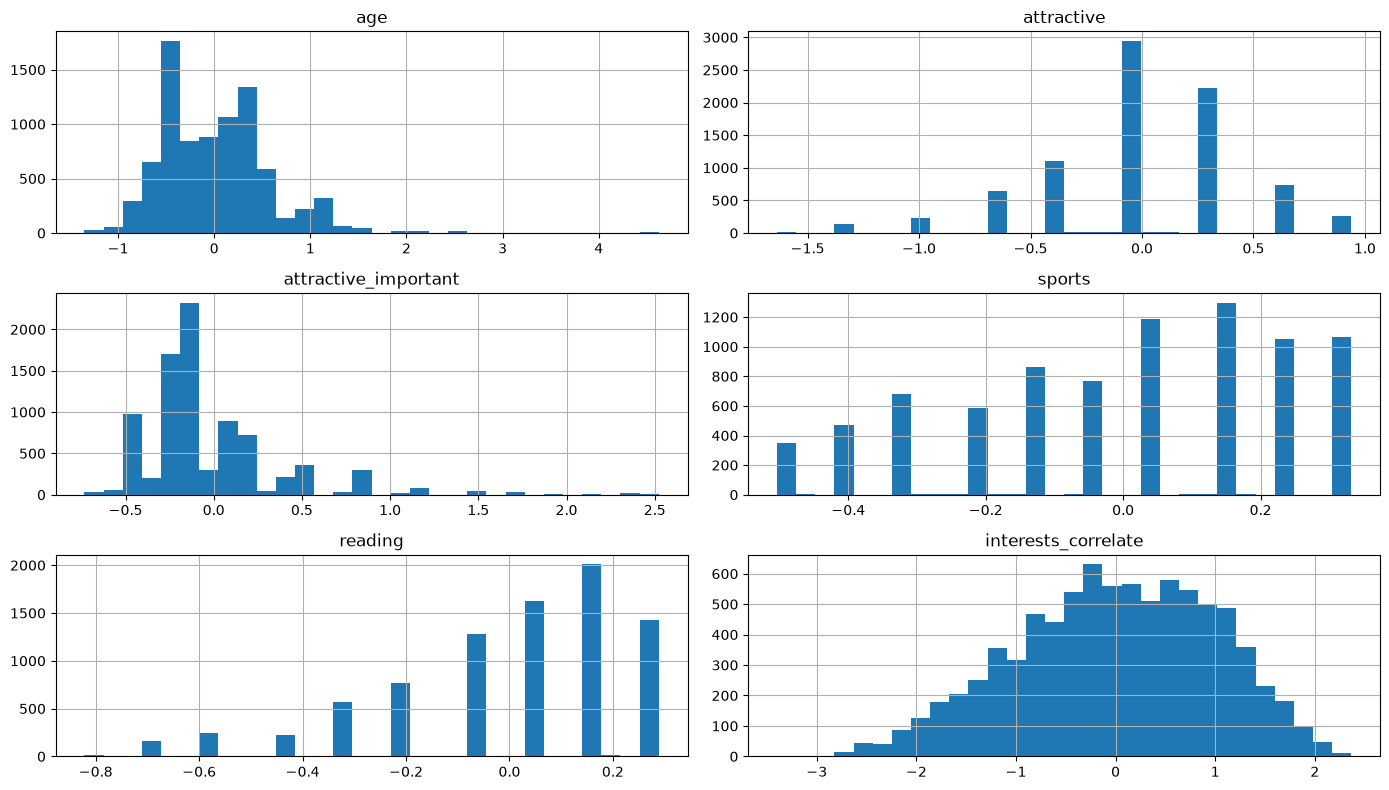

In [31]:
sample_cols = ['age', 'attractive', 'attractive_important', 'sports', 'reading', 'interests_correlate']
X_imputed[sample_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

## Output

| File | Purpose |
|---|---|
| `X_scaled.csv` | all 83 features — input for clustering |
| `X_scaled_no_outcome.csv` | 81 features, without `like` and `guess_prob_liked` |
| `X_unscaled.csv` | original units — needed to interpret cluster centroids |
| `metadata.csv` | `wave`, `match`, `person_id`, `row_id` — **not** used in clustering |
| `models/` | fitted scaler, kNN imputer, and the full preprocessing configuration |

**Why two feature sets.** `like` ("how much I liked my partner") and `guess_prob_liked`
are near-proxies for the decision that produces `match`. Clustering with them and then
reporting "this cluster has a 30% match rate" is partly circular. The `no_outcome` set is
the honest baseline, where `match` remains an independent validation signal; the full set
is retained as a comparison model.

The two sets are imputed **independently**. Dropping the outcome columns after a single
shared imputation would not be enough: kNN selects neighbours using every available column,
so all 11585 imputed values would still carry a trace of the outcome. Two separate passes
keep the baseline genuinely clean.

In [32]:
scale_map = pd.Series({c: block_scales_final[name] for name, cols in BLOCKS.items() for c in cols})

X_unscaled = X_imputed.copy()
X_unscaled[ALL_COLS] = X_unscaled[ALL_COLS] / scale_map
X_unscaled[ALL_COLS] = scaler.inverse_transform(X_unscaled[ALL_COLS])

X_imputed.to_csv('../data/processed/X_scaled.csv', index=False)
X_imputed_no_out.to_csv('../data/processed/X_scaled_no_outcome.csv', index=False)
X_unscaled.to_csv('../data/processed/X_unscaled.csv', index=False)

meta['person_id'] = person_id
meta['row_id'] = range(len(meta))
meta.to_csv('../data/processed/metadata.csv', index=False)

joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(knn_imputer, '../models/knn_imputer.joblib')
joblib.dump(knn_imputer_no_out, '../models/knn_imputer_no_outcome.joblib')

with open('../models/preprocessing_config.json', 'w') as f:
    json.dump({
        'blocks': BLOCKS,
        'block_scales': block_scales_final,
        'block_scales_no_outcome': block_scales_no_out,
        'outcome_cols': OUTCOME_COLS,
        'random_state': RANDOM_STATE
    }, f, indent=2)

print("Saved:")
print(f"  X_scaled.csv             {X_imputed.shape}")
print(f"  X_scaled_no_outcome.csv  {X_imputed_no_out.shape}   (imputed independently)")
print(f"  X_unscaled.csv           {X_unscaled.shape}")
print(f"  metadata.csv             {meta.shape}")
print("  models/: scaler, both imputers, config")

Saved:
  X_scaled.csv             (8378, 83)
  X_scaled_no_outcome.csv  (8378, 81)   (imputed independently)
  X_unscaled.csv           (8378, 83)
  metadata.csv             (8378, 4)
  models/: scaler, both imputers, config
